## Разведочный анализ данных (EDA)

1. Выполним извлечение признаков из текстовых наборов данных.
2. Сгруппируем полученные данные по источнику (человек или ИИ), по используемой модели (LLM), а также по типу промпта (шаблоны 1–5).
3. Построим визуализации для сравнения распределений признаков между группами.
4. Снизим размерность и построим двумерные проекции с использованием PCA и t-SNE.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
from scipy.stats import entropy as scipy_entropy
import string
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nltk.download("punkt")
nltk.download("stopwords")

SEED = 42

[nltk_data] Downloading package punkt to /Users/artfultom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/artfultom/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Загрузка ИИ датасетов

In [2]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]

dfs = []
for f in filenames:
    df = pd.read_csv(f)
    
    model = re.search(r'../datasets/(.*?)_essays', f).group(1)
    prompt_id = int(re.search(r'_(\d)\.csv', f).group(1))
    
    df["model"] = model
    df["prompt_id"] = prompt_id
    df["label"] = 1
    
    dfs.append(df[["text", "label", "model", "prompt_id"]])

df_ai = pd.concat(dfs, ignore_index=True)

### Загрузка эссе, написанных человеком

In [3]:
df_human = (
    pd.read_csv("../datasets/ivy_panda_essays.csv")
    .assign(label=0, model="human", prompt_id=0)
    [["text", "label", "model", "prompt_id"]]
)

In [4]:
print(f"Загружено {len(df_ai)} записей, сгенерированных ИИ")
print(f"Загружено {len(df_human)} записей, написанных человеком")

Загружено 37488 записей, сгенерированных ИИ
Загружено 128293 записей, написанных человеком


In [5]:
df_all = pd.concat([df_ai, df_human], ignore_index=True).sample(frac=1, random_state=SEED)

## Построение признаков для EDA

Признаки:
1. `char_count` — количество символов.
2. `word_count` — количество слов.
3. `avg_word_length` - средняя длина слова.
4. `sentence_count` — количество предложений.
5. `stopword_ratio` — доля стоп-слов.
6. `unique_word_ratio` — доля уникальных слов.
7. `mean_sent_len` — средняя длина предложения.
8. `burstiness` — вариативность длины предложений. Отражает степень колебаний длины предложений. Высокое значение указывает на чередование коротких и длинных конструкций.
9. `shannon_entropy` — энтропия Шеннона. Характеризует разнообразие и равномерность словоупотребления. Чем выше значение, тем более разнообразен словарь текста.
10. `punct_ratio` — доля пунктуации. Отношение количества символов пунктуации к общей длине текста.

In [6]:
stop_words = set(stopwords.words("english"))

In [7]:
def extract_features(text):
    sentences = sent_tokenize(text)
    words = [w.lower() for w in word_tokenize(text) if w.isalpha()]

    sent_lengths = [len([w for w in word_tokenize(s) if w.isalpha()])
                    for s in sentences if s.strip()]

    mean_sent_len = np.mean(sent_lengths) if sent_lengths else 0
    std_sent_len = np.std(sent_lengths) if sent_lengths else 0
    burstiness = std_sent_len / mean_sent_len if mean_sent_len else 0

    word_counts = pd.Series(words).value_counts()
    probabilities = word_counts / word_counts.sum()
    shannon_entropy = scipy_entropy(probabilities)

    punct_ratio = sum(text.count(p) for p in string.punctuation) / len(text) if text else 0

    return pd.Series({
        "char_count": len(text),
        "word_count": len(words),
        "avg_word_length": np.mean([len(w) for w in words]),
        "sentence_count": len(sentences),
        "stopword_ratio": sum(w in stop_words for w in words) / len(words),
        "unique_word_ratio": len(set(words)) / len(words),
        "mean_sent_len": mean_sent_len,
        "burstiness": burstiness,
        "shannon_entropy": shannon_entropy,
        "punct_ratio": punct_ratio,
    })

In [8]:
df_features = df_all["text"].apply(extract_features)
df_all = pd.concat([df_all, df_features], axis=1)

## ИИ vs Человек

### Распределение длины текста

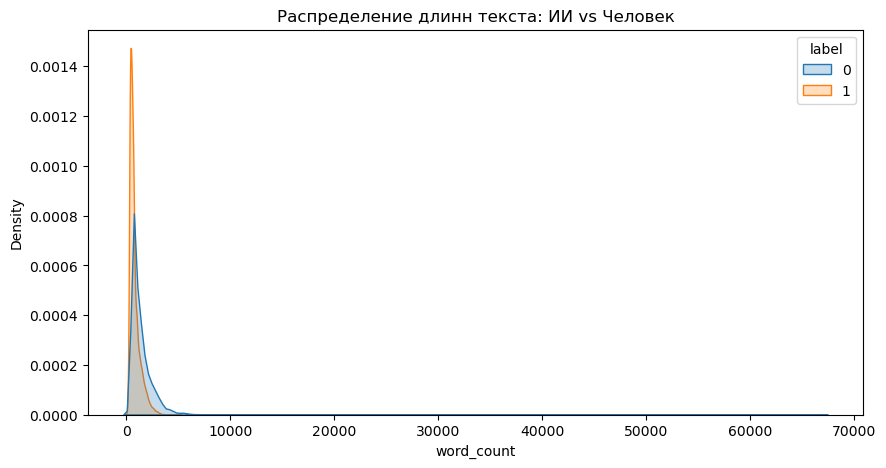

In [9]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_all, x="word_count", hue="label", fill=True, common_norm=False)
plt.title("Распределение длинн текста: ИИ vs Человек")
plt.show()

### Boxplot признаков

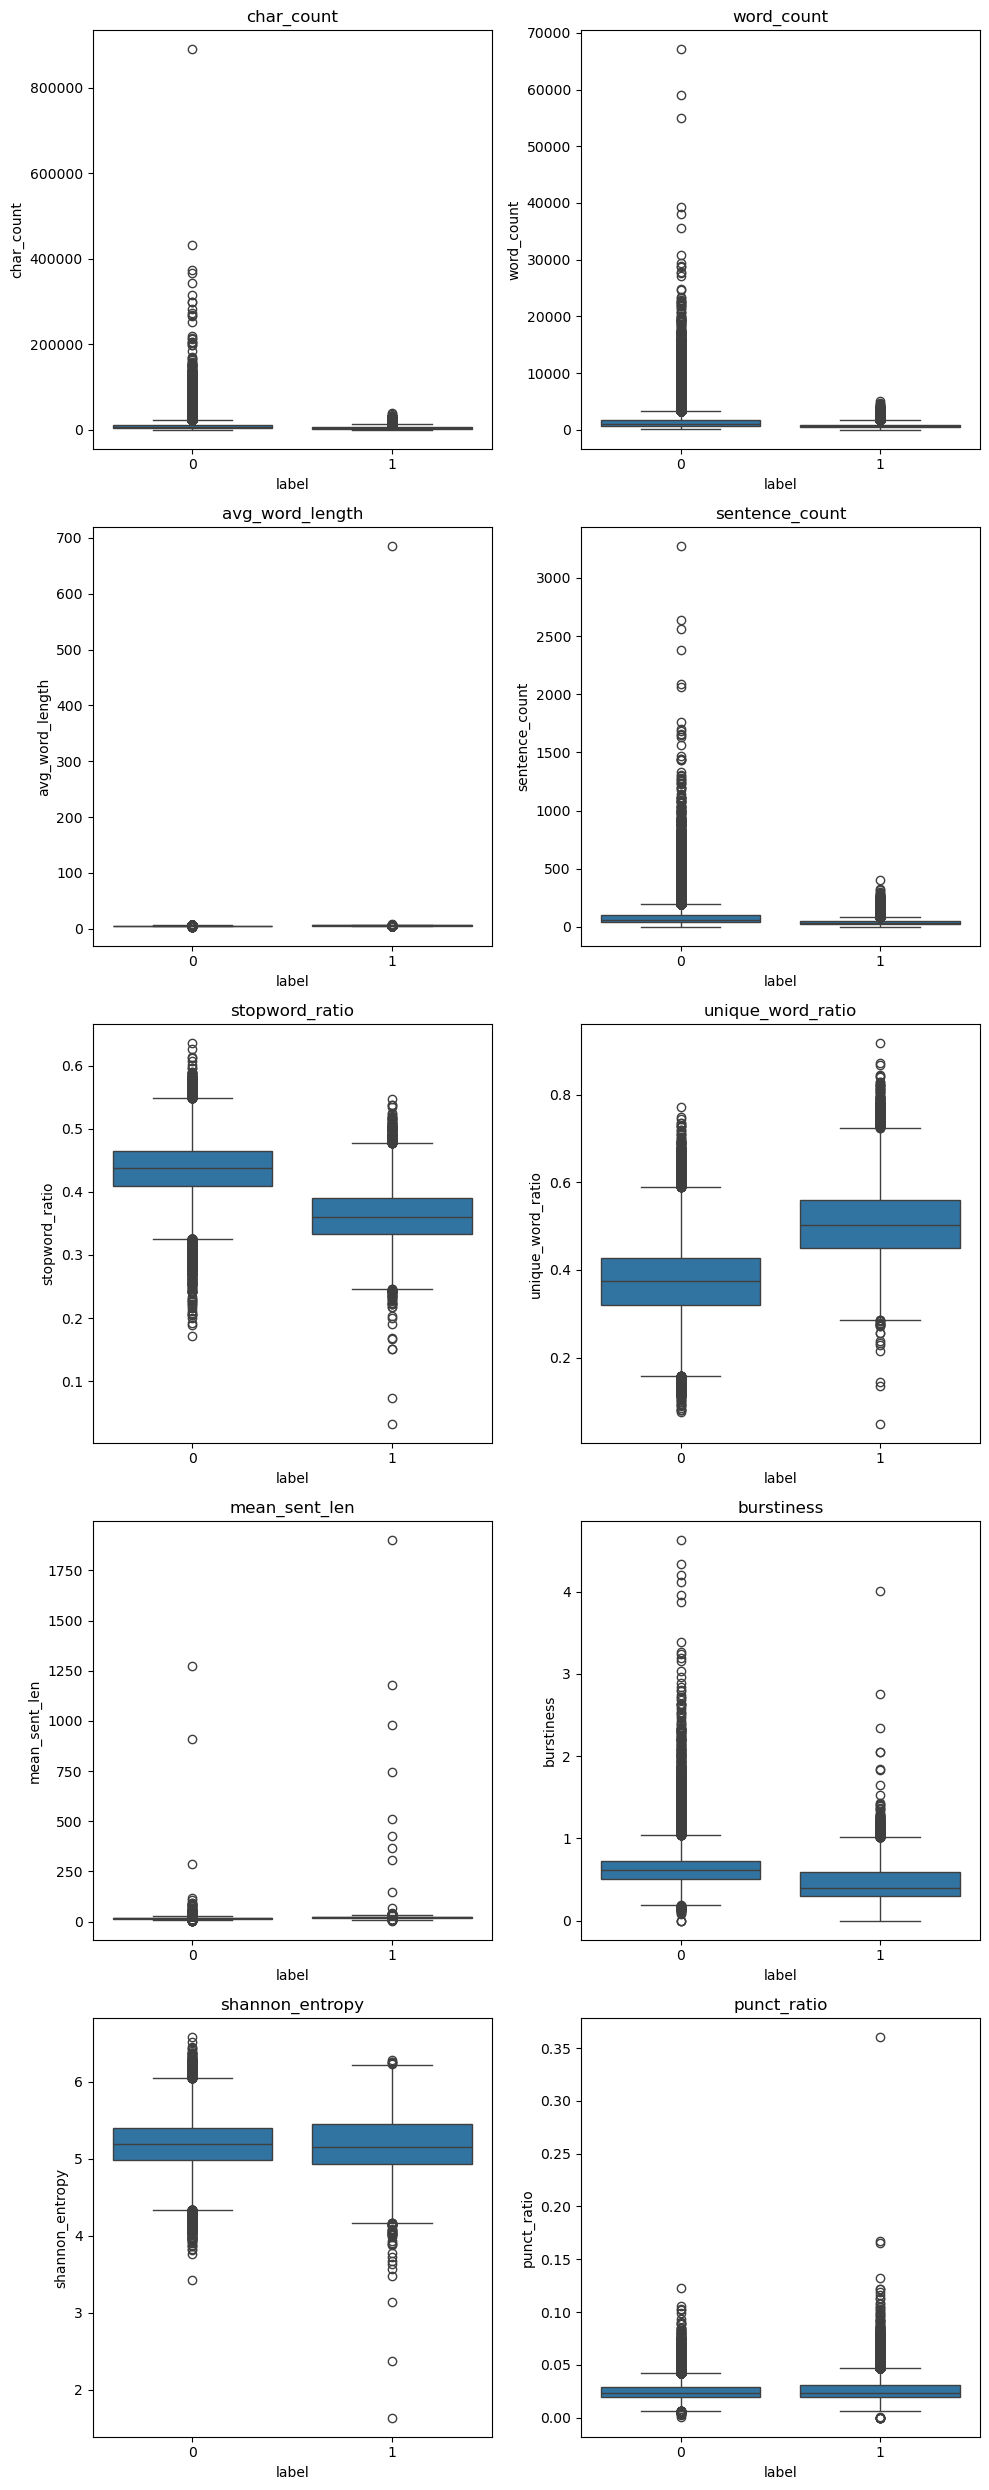

In [10]:
features = [
    "char_count",
    "word_count",
    "avg_word_length",
    "sentence_count",
    "stopword_ratio",
    "unique_word_ratio",
    "mean_sent_len",
    "burstiness",
    "shannon_entropy",
    "punct_ratio"
]

plt.figure(figsize=(10, 25))

for i, feat in enumerate(features):
    plt.subplot(5, 2, i + 1)
    sns.boxplot(data=df_all, x="label", y=feat)
    plt.title(feat)

plt.tight_layout()
plt.show()

## Сравнение разных моделей

### Средние значения по моделям

In [11]:
df_model_stats = df_all[df_all.label == 1].groupby("model")[features].mean()
df_model_stats.head(5)

,char_count,word_count,avg_word_length,sentence_count,stopword_ratio,unique_word_ratio,mean_sent_len,burstiness,shannon_entropy,punct_ratio
model,,,,,,,,,,
chatgpt,6548.788500,858.807100,6.098124,43.955600,0.350649,0.516458,20.795887,0.400387,5.277267,0.023642
deepseek,6615.119741,893.178745,5.958811,40.755917,0.367215,0.525985,22.971615,0.433346,5.356510,0.024041
llama,3474.095009,469.411505,5.856117,27.313089,0.376923,0.488586,19.205639,0.529813,4.910445,0.034450
mistral,3905.324267,522.255333,5.864058,32.836400,0.360178,0.474125,17.066711,0.531231,4.967159,0.031136


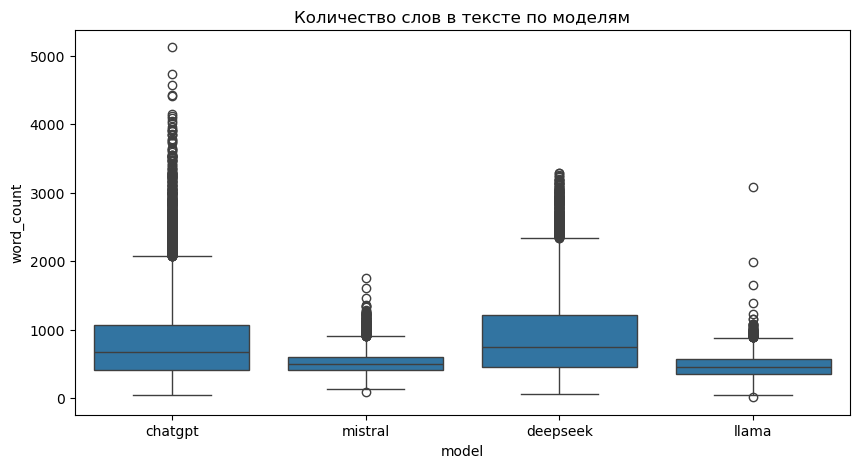

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all[df_all.label == 1], x="model", y="word_count")
plt.title("Количество слов в тексте по моделям")
plt.show()

## Сравнение разных промптов

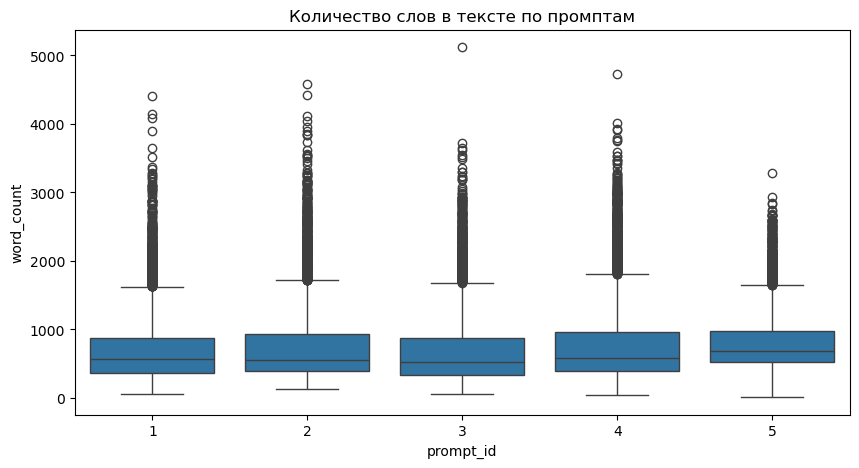

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all[df_all.label == 1], x="prompt_id", y="word_count")
plt.title("Количество слов в тексте по промптам")
plt.show()

## Частотный анализ слов

### Топ слова для ИИ и человека

In [14]:
def get_top_words(texts, n=20):
    all_words = []
    
    for t in texts:
        words = [
            w.lower() 
            for w in word_tokenize(t)
            if w.isalpha() and w.lower() not in stop_words
        ]
        all_words.extend(words)
        
    return Counter(all_words).most_common(n)

print("ТОП слов в живых текстах:")
print(get_top_words(df_all[df_all.label == 0].text))

print("\nТОП слов в синтетических текстах:")
print(get_top_words(df_all[df_all.label == 1].text))

ТОП слов в живых текстах:
[('also', 483907), ('people', 460253), ('one', 419546), ('company', 351108), ('new', 327612), ('may', 262907), ('management', 252391), ('however', 245548), ('business', 244104), ('would', 240755), ('social', 238991), ('time', 232024), ('use', 230690), ('different', 220525), ('research', 218343), ('information', 216121), ('used', 215437), ('world', 210431), ('market', 210100), ('many', 205488)]

ТОП слов в синтетических текстах:
[('social', 75392), ('health', 72356), ('often', 51203), ('also', 51152), ('significant', 40341), ('within', 40192), ('may', 39908), ('public', 39904), ('care', 39458), ('one', 38404), ('cultural', 36985), ('critical', 36780), ('research', 36008), ('human', 35669), ('economic', 35492), ('data', 35491), ('management', 35478), ('challenges', 34963), ('healthcare', 34502), ('conclusion', 34060)]


### Вывод

#### Живые тексты

- people, company, market, business - более конкретная лексика. Тексты чаще оперируют реальными субъектами и объектами.
- use, used, would - eсть динамика, действия.

#### Синтетические тексты

- significant, critical, economic, cultural - более абстрактная и академическая лексика.
- conclusion - шаблонность.

Синтетические тексты характеризуются большей долей абстрактных и академически окрашенных слов, тогда как в текстах, написанных человеком, чаще встречается конкретная предметная лексика.

## PCA Визуализация

In [15]:
X = df_all[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_all["PCA1"] = X_pca[:,0]
df_all["PCA2"] = X_pca[:,1]

### PCA: ИИ vs Человек

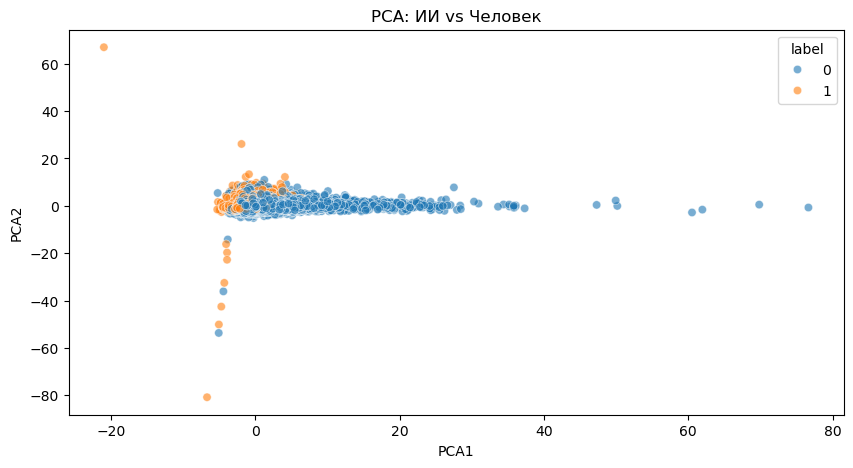

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_all, x="PCA1", y="PCA2", hue="label", alpha=0.6)
plt.title("PCA: ИИ vs Человек")
plt.show()

### PCA: Разные модели

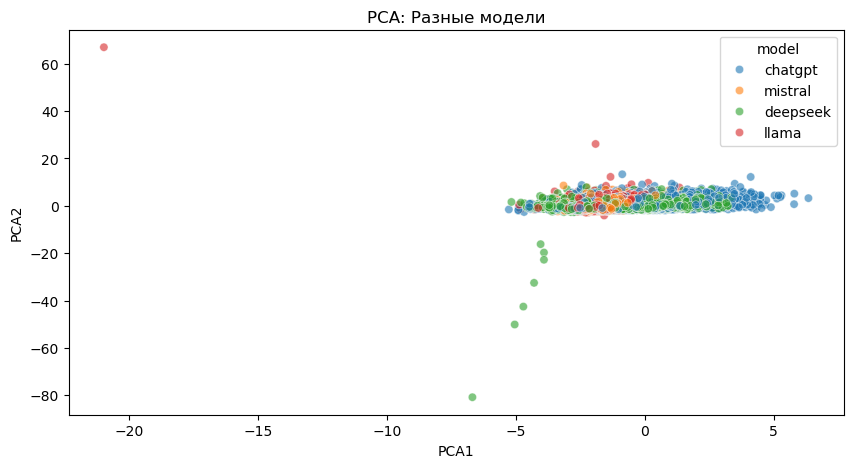

In [17]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_all[df_all.label==1], x="PCA1", y="PCA2", hue="model", alpha=0.6)
plt.title("PCA: Разные модели")
plt.show()

### PCA: Разные промпты

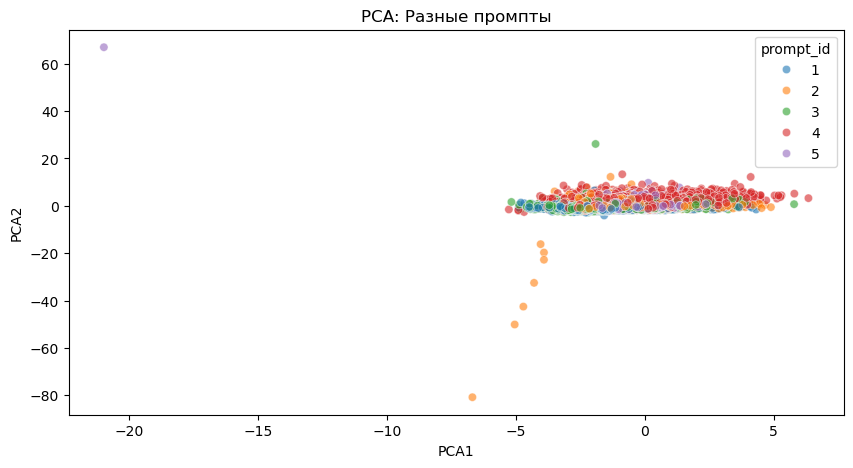

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_all[df_all.label==1], x="PCA1", y="PCA2", hue="prompt_id", palette="tab10", alpha=0.6)
plt.title("PCA: Разные промпты")
plt.show()

## t-SNE Визуализация

In [19]:
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)

X_tsne = tsne.fit_transform(X_scaled)

df_all["TSNE1"] = X_tsne[:,0]
df_all["TSNE2"] = X_tsne[:,1]

### t-SNE: ИИ vs Человек

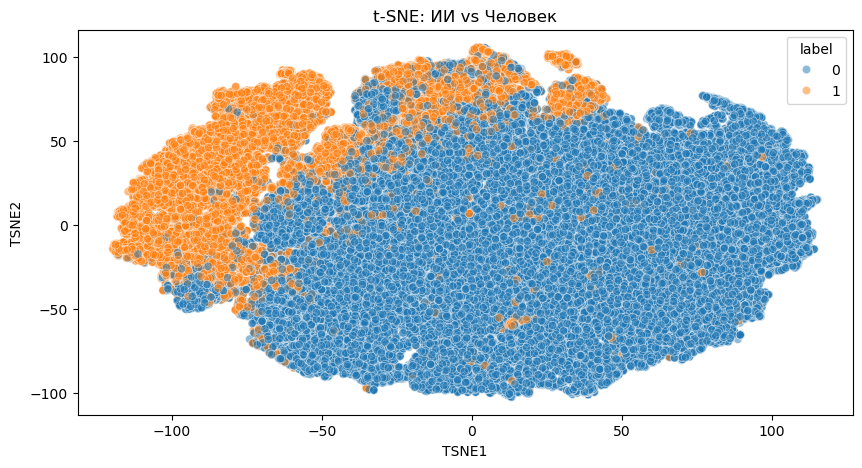

In [20]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_all, x="TSNE1", y="TSNE2", hue="label", alpha=0.5)
plt.title("t-SNE: ИИ vs Человек")
plt.show()

### t-SNE: Разные модели

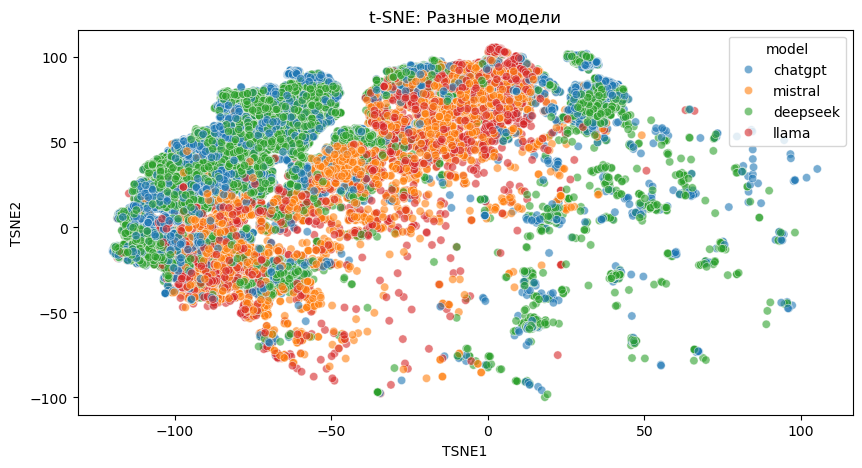

In [21]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_all[df_all.label==1], x="TSNE1", y="TSNE2", hue="model", alpha=0.6)
plt.title("t-SNE: Разные модели")
plt.show()

### t-SNE: Разные промпты

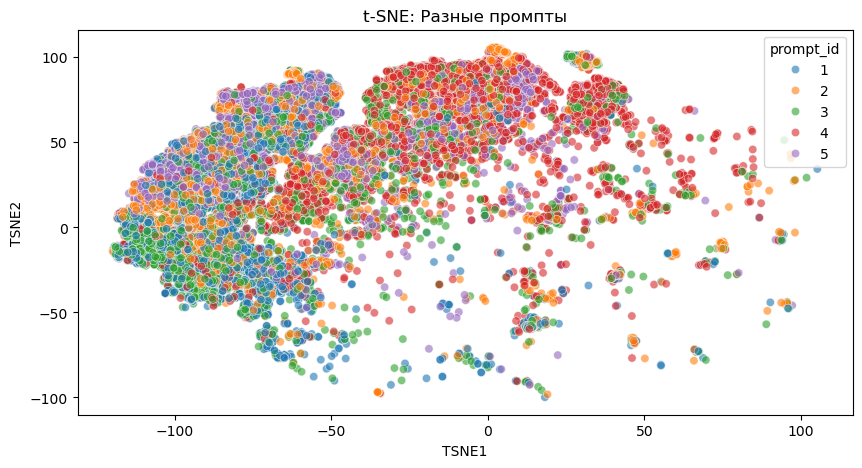

In [22]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_all[df_all.label==1], x="TSNE1", y="TSNE2", hue="prompt_id", palette="tab10", alpha=0.6)
plt.title("t-SNE: Разные промпты")
plt.show()

## Выводы

Визуализация признаков с помощью PCA и t-SNE показала, что тексты, написанные человеком и сгенерированные ИИ, в целом образуют единое облако точек, однако при этом между ними прослеживается различие. Кластеры частично перекрываются, но наблюдается определённая разница, позволяющая отделить классы на уровне распределения признаков.

При анализе полного набора признаков: различия между моделями и различными промптами генерации выражены слабо и не приводят к формированию устойчивых кластеров. В то же время различие между текстами, написанными человеком, и синтетическими текстами прослеживается достаточно отчётливо, однако его недостаточно для построения точной классификации.